# Louvain



In [ ]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# ── Rete climate_19 ──────────────────────────────────────────────────────
g = ig.Graph.Read_GraphML(r"C:\Users\giuli\OneDrive\Documenti\UNI\MAGISTRALE\AnalVisual\AVRC_FinnishTwittersphereProject\Data\climate_19.graphml")
if g.is_directed():
    g = g.as_undirected(combine_edges="first")

N = g.vcount()
E = g.ecount()
group_attr = g.vs["group"]
hier_attr  = g.vs["hierarchy"]

idx_A = [v.index for v in g.vs if v["group"] == "A"]
idx_B = [v.index for v in g.vs if v["group"] == "B"]
sub_idx = {lbl: [v.index for v in g.vs if v["hierarchy"] == lbl]
           for lbl in ["A_CORE","A_PERIPHERY","B_CORE","B_PERIPHERY"]}




climate_19 — Nodi: 16,639  Archi: 50,605  Densità: 0.000366
Comunità A: 7,409  |  B: 9,230


---
## 4. Louvain su con `g.community_multilevel()`

igraph implementa Louvain con `g.community_multilevel()` che:
- esegue l'algoritmo in modo iterativo fino a convergenza
- restituisce un oggetto `VertexClustering` con `.membership`, `.modularity`, e `.subgraphs()`
- accetta il parametro `resolution` per controllare la granularità






In [25]:
import time


t0  = time.perf_counter()
vc  = g.community_multilevel(weights=None)
t1  = time.perf_counter()

memb_louvain = vc.membership
Q_louvain    = g.modularity(memb_louvain)
k_louvain    = len(set(memb_louvain))

print(f"Tempo          : {(t1-t0)*1000:.0f} ms")
print(f"Comunità trovate: {k_louvain}")
print(f"Q (igraph)     : {Q_louvain:.4f}")
print()

# Dimensioni comunità
comm_sizes = Counter(memb_louvain)
print("Dimensioni comunità (ordinate per dimensione decrescente):")
size_df = pd.DataFrame(
    sorted(comm_sizes.items(), key=lambda x: -x[1]),
    columns=["comm_id", "n_nodi"]
)
size_df["fraz_%"] = (size_df["n_nodi"] / N * 100).round(2)
display(size_df)


Tempo          : 544 ms
Comunità trovate: 92
Q (igraph)     : 0.5246

Dimensioni comunità (ordinate per dimensione decrescente):


,comm_id,n_nodi,fraz_%
0,0,3799,22.83
1,4,2377,14.29
2,6,1916,11.52
3,12,1719,10.33
4,7,1087,6.53
...,...,...,...
87,84,2,0.01
88,87,2,0.01
89,89,2,0.01
90,90,2,0.01


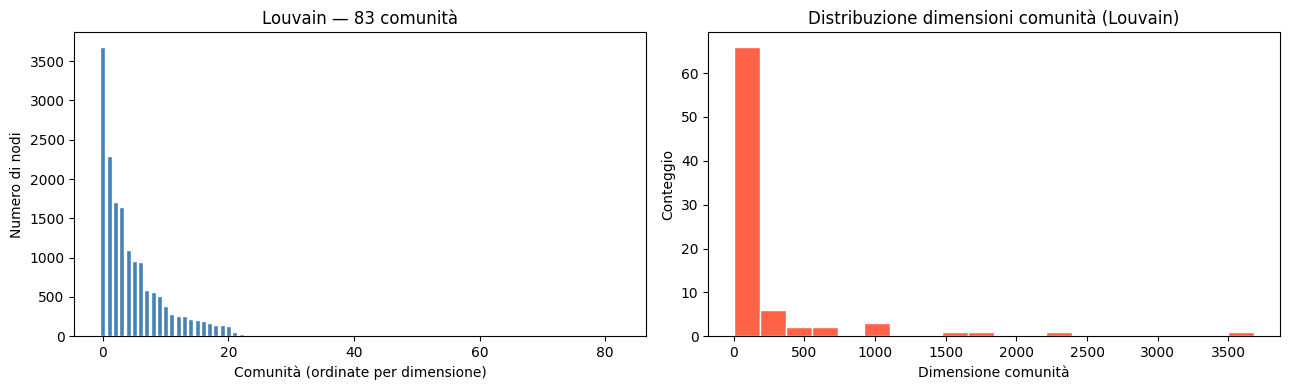

In [21]:
# ── Distribuzione dimensioni ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sizes_sorted = sorted(comm_sizes.values(), reverse=True)
ax = axes[0]
ax.bar(range(len(sizes_sorted)), sizes_sorted, color="steelblue", edgecolor="white")
ax.set_xlabel("Comunità (ordinate per dimensione)")
ax.set_ylabel("Numero di nodi")
ax.set_title(f"Louvain — {k_louvain} comunità")

ax2 = axes[1]
ax2.hist(sizes_sorted, bins=20, color="tomato", edgecolor="white")
ax2.set_xlabel("Dimensione comunità")
ax2.set_ylabel("Conteggio")
ax2.set_title("Distribuzione dimensioni comunità (Louvain)")
plt.tight_layout(); plt.show()



## 30 run con seed diversi




In [ ]:

stability_rows = []
all_memberships = []

for s in range(30):
    # igraph non ha un parametro seed diretto per community_multilevel;
    # impostiamo il seed globale di numpy e shuffliamo l'ordine dei nodi
    np.random.seed(s)
    g_shuffled = g.permute_vertices(np.random.permutation(N).tolist())
    vc_s = g_shuffled.community_multilevel(weights=None)
    # ri-mappiamo il membership sull'ordine originale dei nodi
    # (permute_vertices riordina i nodi, quindi invertiamo la permutazione)
    perm = np.random.permutation(N)   # stessa seed → stessa permutazione
    np.random.seed(s)
    perm = np.random.permutation(N)
    inv_perm = np.argsort(perm)
    memb_s = [vc_s.membership[inv_perm[i]] for i in range(N)]

    Q_s = g.modularity(memb_s)
    k_s = len(set(memb_s))
    stability_rows.append({"seed": s, "k": k_s, "Q": round(Q_s, 4)})
    all_memberships.append(memb_s)

stab_df = pd.DataFrame(stability_rows)
print(f"Q    — min: {stab_df['Q'].min():.4f}  max: {stab_df['Q'].max():.4f}  "
      f"mean: {stab_df['Q'].mean():.4f}  std: {stab_df['Q'].std():.4f}")
print(f"k    — min: {stab_df['k'].min()}  max: {stab_df['k'].max()}  "
      f"mean: {stab_df['k'].mean():.1f}")
display(stab_df.describe().round(4))


Q    — min: 0.5220  max: 0.5346  mean: 0.5271  std: 0.0037
k    — min: 42  max: 97  mean: 72.1


,seed,k,Q
count,30.0000,30.000,30.0000
mean,14.5000,72.100,0.5271
std,8.8034,16.953,0.0037
min,0.0000,42.000,0.5220
25%,7.2500,55.500,0.5246
50%,14.5000,76.500,0.5261
75%,21.7500,85.750,0.5284
max,29.0000,97.000,0.5346


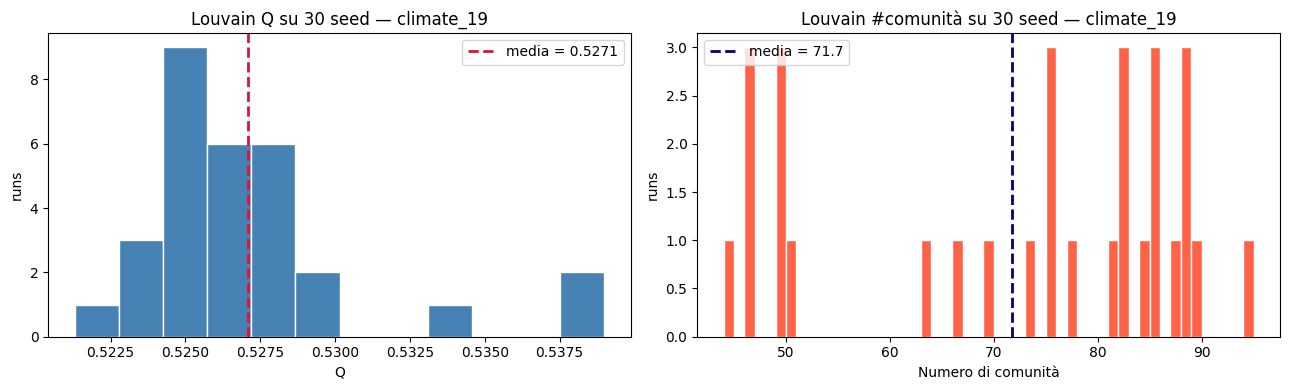

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(stab_df["Q"], bins=12, color="steelblue", edgecolor="white")
ax.axvline(stab_df["Q"].mean(), color="crimson", linewidth=2, linestyle="--",
           label=f'media = {stab_df["Q"].mean():.4f}')
ax.set_xlabel("Q"); ax.set_ylabel("runs")
ax.set_title("Louvain Q su 30 seed")
ax.legend()

ax2 = axes[1] #non so bene che senso abbia questo plot
ax2.hist(stab_df["k"],
         bins=range(stab_df["k"].min(), stab_df["k"].max()+2),
         color="tomato", edgecolor="white")
ax2.axvline(stab_df["k"].mean(), color="navy", linewidth=2, linestyle="--",
            label=f'media = {stab_df["k"].mean():.1f}')
ax2.set_xlabel("Numero di comunità"); ax2.set_ylabel("runs")
ax2.set_title("Louvain #comunità su 30 seed ")
ax2.legend()
plt.tight_layout(); plt.show()


---
## 6. Confronto con la partizione ground-truth A/B

Usiamo due indici per misurare quanto la partizione Louvain assomiglia alla
partizione originale A/B:

- **NMI** (Normalized Mutual Information): misura la mutua informazione tra le due partizioni, normalizzata in [0,1]. 1 = partizioni identiche.
- **ARI** (Adjusted Rand Index): conta le coppie di nodi classificate nello stesso modo, corretta per il caso. 1 = perfetto, 0 = casuale.
- **VI** è per verificare l'accordo tra queste due metriche




In [11]:
# Ground truth membership: 0=A, 1=B
gt_membership = [0 if g.vs[i]["group"] == "A" else 1 for i in range(N)]

# Confronto NMI e ARI tra Louvain (run principale) e ground truth
nmi = ig.compare_communities(gt_membership, memb_louvain, method="nmi")
ari = ig.compare_communities(gt_membership, memb_louvain, method="adjusted_rand")
vi  = ig.compare_communities(gt_membership, memb_louvain, method="vi")

print(f"Confronto Louvain vs ground truth A/B:")
print(f"  NMI (Normalized Mutual Information) : {nmi:.4f}  [0=cas., 1=ideale]")
print(f"  ARI (Adjusted Rand Index)           : {ari:.4f}  [0=cas., 1=ideale]")
print(f"  VI  (Variation of Information)      : {vi:.4f}  [0=ideale, ↑=più diverso]")


Confronto Louvain vs ground truth A/B:
  NMI (Normalized Mutual Information) : 0.2407  [0=cas., 1=ideale]
  ARI (Adjusted Rand Index)           : 0.1605  [0=cas., 1=ideale]
  VI  (Variation of Information)      : 2.5417  [0=ideale, ↑=più diverso]


In [12]:
# NMI e ARI su tutti i 30 seed
compare_rows = []
for s, memb_s in enumerate(all_memberships):
    nmi_s = ig.compare_communities(gt_membership, memb_s, method="nmi")
    ari_s = ig.compare_communities(gt_membership, memb_s, method="adjusted_rand")
    compare_rows.append({"seed": s, "NMI": round(nmi_s,4), "ARI": round(ari_s,4),
                          "k": stab_df.loc[s,"k"], "Q": stab_df.loc[s,"Q"]})

cmp_df = pd.DataFrame(compare_rows)
print("Statistiche NMI e ARI su 30 seed:")
display(cmp_df[["NMI","ARI","k","Q"]].describe().round(4))


Statistiche NMI e ARI su 30 seed:


,NMI,ARI,k,Q
count,30.0000,30.0000,30.0000,30.0000
mean,0.2343,0.1530,71.7333,0.5271
std,0.0095,0.0092,16.4609,0.0039
min,0.2095,0.1311,44.0000,0.5213
25%,0.2303,0.1464,53.2500,0.5251
50%,0.2355,0.1523,76.0000,0.5261
75%,0.2398,0.1589,85.0000,0.5276
max,0.2541,0.1687,94.0000,0.5390


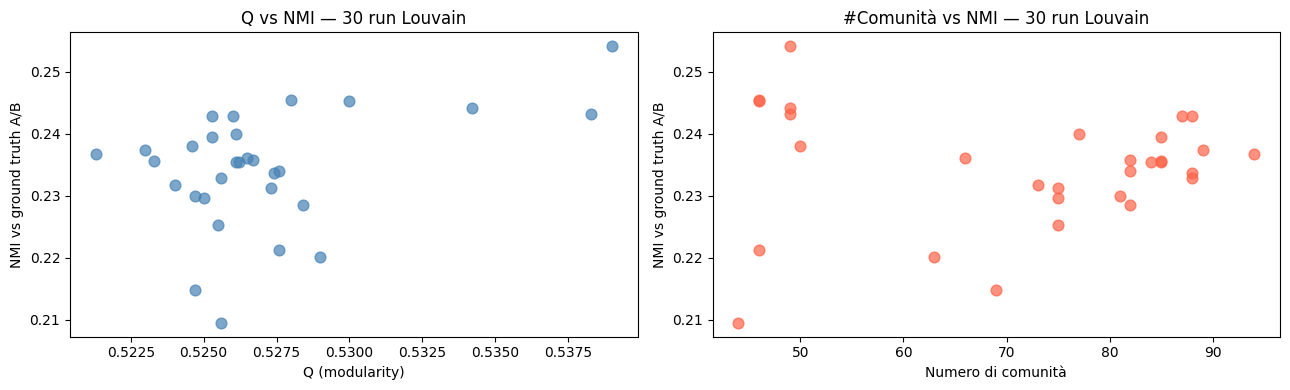

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(cmp_df["Q"], cmp_df["NMI"], color="steelblue", alpha=0.7, s=60)
ax.set_xlabel("Q (modularity)"); ax.set_ylabel("NMI vs ground truth A/B")
ax.set_title("Q vs NMI — 30 run Louvain")

ax2 = axes[1]
ax2.scatter(cmp_df["k"], cmp_df["NMI"], color="tomato", alpha=0.7, s=60)
ax2.set_xlabel("Numero di comunità"); ax2.set_ylabel("NMI vs ground truth A/B")
ax2.set_title("#Comunità vs NMI — 30 run Louvain")
plt.tight_layout(); plt.show()


---
## 7. Analisi delle comunità trovate

Esaminiamo la composizione di ogni comunità Louvain rispetto alla partizione A/B
e alla struttura CORE/PERIPHERY. Non mi sembra molto interessante...


In [14]:
# Per ogni comunità Louvain: quanti nodi A vs B, quanti CORE vs PERIPHERY
analysis_rows = []
for c in sorted(set(memb_louvain)):
    members = [i for i, m in enumerate(memb_louvain) if m == c]
    n_A     = sum(1 for i in members if g.vs[i]["group"] == "A")
    n_B     = sum(1 for i in members if g.vs[i]["group"] == "B")
    n_core  = sum(1 for i in members if "CORE" in g.vs[i]["hierarchy"])
    n_peri  = sum(1 for i in members if "PERIPHERY" in g.vs[i]["hierarchy"])
    sub_c   = g.induced_subgraph(members)
    nc      = sub_c.vcount()
    delta   = (2 * sub_c.ecount() / (nc*(nc-1))) if nc > 1 else 0
    dominant = "A" if n_A >= n_B else "B"
    analysis_rows.append({
        "comm_id"   : c,
        "|C|"       : len(members),
        "n_A"       : n_A,
        "n_B"       : n_B,
        "fraz_A"    : round(n_A/len(members), 3),
        "dominant"  : dominant,
        "n_CORE"    : n_core,
        "n_PERIPH"  : n_peri,
        "δ_int"     : round(delta, 5),
    })

analysis_df = pd.DataFrame(analysis_rows).sort_values("|C|", ascending=False)
display(analysis_df)


,comm_id,|C|,n_A,n_B,fraz_A,dominant,n_CORE,n_PERIPH,δ_int
0,0,3682,3636,46,0.988,A,290,3392,0.00238
6,6,2287,66,2221,0.029,B,221,2066,0.00243
12,12,1711,234,1477,0.137,B,13,1698,0.00136
13,13,1638,376,1262,0.230,B,63,1575,0.00192
11,11,1103,1015,88,0.920,A,24,1079,0.00226
...,...,...,...,...,...,...,...,...,...
78,78,2,0,2,0.000,B,0,2,1.00000
79,79,2,2,0,1.000,A,0,2,1.00000
80,80,2,0,2,0.000,B,0,2,1.00000
81,81,2,2,0,1.000,A,0,2,1.00000


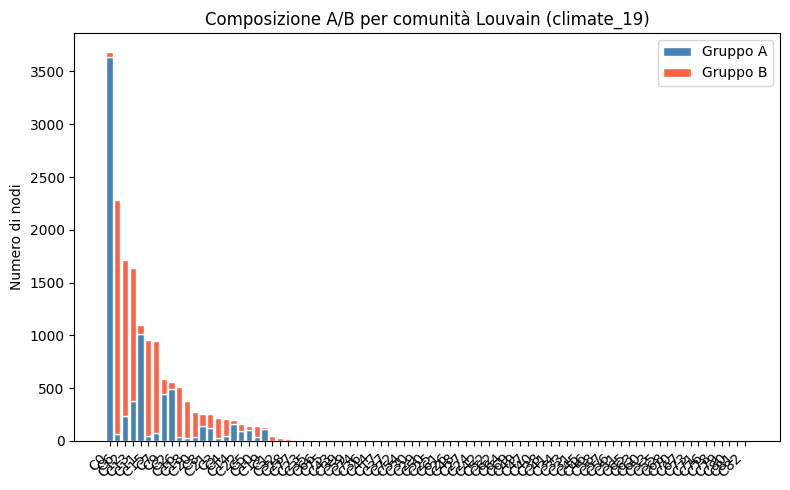

In [20]:
# Mappa visiva: per ogni comunità Louvain, bar stacked A vs B
fig, ax = plt.subplots(figsize= (8,5) )   #(max(8, k_louvain*0.7), ))
df_plot = analysis_df.sort_values("|C|", ascending=False).reset_index(drop=True)
xs = range(len(df_plot))
ax.bar(xs, df_plot["n_A"], color="steelblue", label="Gruppo A", edgecolor="white")
ax.bar(xs, df_plot["n_B"], bottom=df_plot["n_A"], color="tomato",
       label="Gruppo B", edgecolor="white")
ax.set_xticks(list(xs))
ax.set_xticklabels([f"C{row.comm_id}" for _, row in df_plot.iterrows()],
                   rotation=45, ha="right")
ax.set_ylabel("Numero di nodi")
ax.set_title("Composizione A/B per comunità Louvain (climate_19)")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
# Sankey-style summary: quante comunità Louvain sono "prevalentemente A" vs "prevalentemente B"
dominant_count = Counter(analysis_df["dominant"])
print("Comunità Louvain per gruppo dominante:")
for k, v in sorted(dominant_count.items()):
    sub = analysis_df[analysis_df["dominant"]==k]
    tot_nodi = sub["|C|"].sum()
    print(f"  Dominante {k}: {v} comunità, {tot_nodi:,} nodi totali "
          f"({100*tot_nodi/N:.1f}% della rete)")


Comunità Louvain per gruppo dominante:
  Dominante A: 44 comunità, 6,920 nodi totali (41.6% della rete)
  Dominante B: 39 comunità, 9,719 nodi totali (58.4% della rete)


---
## Da notare

- **Q elevato** rispetto alla baseline casuale : la struttura
  comunitaria è genuina.
- **Più di 2 comunità**: Louvain risolve la rete a granularità più fine rispetto alla
  semplice dicotomia A/B. Esistono sotto-bolle all'interno dei due grandi gruppi —
  il *resolution limit* può però causare frammentazione artificiale
  delle comunità più piccole.
- **Stabilità**: Q varia poco tra i 30 seed (std basso), ma il numero di comunità
  e i dettagli del membership possono cambiare — degeneracy tipica di Louvain.


- **NMI** misura quanto la partizione Louvain "spiega" la label A/B: un valore
  elevato indica che le comunità Louvain si allineano bene con la polarizzazione
  A/B, anche se le suddividono ulteriormente.
- **ARI** conferma o smentisce il risultato: se è vicino a NMI, le due metriche
  concordano.





## Leiden

Come notato nel tutorial, Louvain può produrre comunità internamente disconnesse
(un difetto strutturale). L'algoritmo **Leiden** (`g.community_leiden()` in igraph)
risolve questo problema ed è oggi la scelta preferita in pratica — prova a
sostituire `community_multilevel` con `community_leiden` e confronta i risultati!

In [26]:
import time


t0  = time.perf_counter()
vc  = g.community_leiden(weights=None)
t1  = time.perf_counter()

memb_leiden = vc.membership
Q_leiden    = g.modularity(memb_leiden)
k_leiden    = len(set(memb_leiden))

print(f"Tempo          : {(t1-t0)*1000:.0f} ms")
print(f"Comunità trovate: {k_leiden}")
print(f"Q (igraph)     : {Q_leiden:.4f}")


# Dimensioni comunità
comm_sizes = Counter(memb_leiden)
print("Dimensioni comunità (ordinate per dimensione decrescente):")
size_df = pd.DataFrame(
    sorted(comm_sizes.items(), key=lambda x: -x[1]),
    columns=["comm_id", "n_nodi"]
)
size_df["fraz_%"] = (size_df["n_nodi"] / N * 100).round(2)
display(size_df)

Tempo          : 72 ms
Comunità trovate: 16639
Q (igraph)     : -0.0011
Dimensioni comunità (ordinate per dimensione decrescente):


,comm_id,n_nodi,fraz_%
0,0,1,0.01
1,1,1,0.01
2,2,1,0.01
3,3,1,0.01
4,4,1,0.01
...,...,...,...
16634,16634,1,0.01
16635,16635,1,0.01
16636,16636,1,0.01
16637,16637,1,0.01
